<a href="https://colab.research.google.com/github/sidneyppratt-svg/quant-regime-detector/blob/main/credit_spread_monitor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install yfinance pandas numpy matplotlib seaborn -q
print("✅ All packages installed successfully!")

✅ All packages installed successfully!


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("Downloading credit market data...")

tickers = ['HYG', 'LQD', 'SPY']
prices = yf.download(tickers,
    start='2010-01-01',
    end='2026-09-18',
    auto_adjust=True)['Close']
prices = prices.dropna()
returns = prices.pct_change().dropna()

print(f"✅ Data downloaded successfully!")
print(f"📅 Date range: {prices.index[0].date()} to {prices.index[-1].date()}")
print(f"📊 Total trading days: {len(prices)}")

[*********************100%***********************]  3 of 3 completed

✅ Data downloaded successfully!
📅 Date range: 2010-01-04 to 2026-09-17
📊 Total trading days: 4202


In [3]:
hyg_roll = returns['HYG'].rolling(21).mean()
lqd_roll = returns['LQD'].rolling(21).mean()

spread = (lqd_roll - hyg_roll) * 10000
spread = spread.dropna()

spread_df = pd.DataFrame({
    'spread':       spread,
    'stress_score': pd.cut(
        spread.rank(pct=True) * 100,
        bins=[0, 20, 40, 60, 80, 100],
        labels=[1, 2, 3, 4, 5]
    ).astype(float),
    'spread_smooth': spread.rolling(21).mean()
})

current_spread = spread.iloc[-1]
current_score  = spread_df['stress_score'].iloc[-1]
current_date   = spread.index[-1].strftime('%B %d, %Y')

print("✅ Credit spread calculated!")
print(f"\n📅 As of: {current_date}")
print(f"📊 Current spread: {current_spread:.1f} basis points")
print(f"🌡️  Stress score: {current_score:.0f} out of 5")

if current_score <= 1:
    print("🟢 Status: VERY CALM")
elif current_score <= 2:
    print("🟢 Status: CALM")
elif current_score <= 3:
    print("🟡 Status: MODERATE")
elif current_score <= 4:
    print("🟠 Status: ELEVATED — Credit stress is building")
else:
    print("🔴 Status: HIGH STRESS")

✅ Credit spread calculated!

📅 As of: September 17, 2026
📊 Current spread: 1.2 basis points
🌡️  Stress score: 4 out of 5
🟠 Status: ELEVATED — Credit stress is building


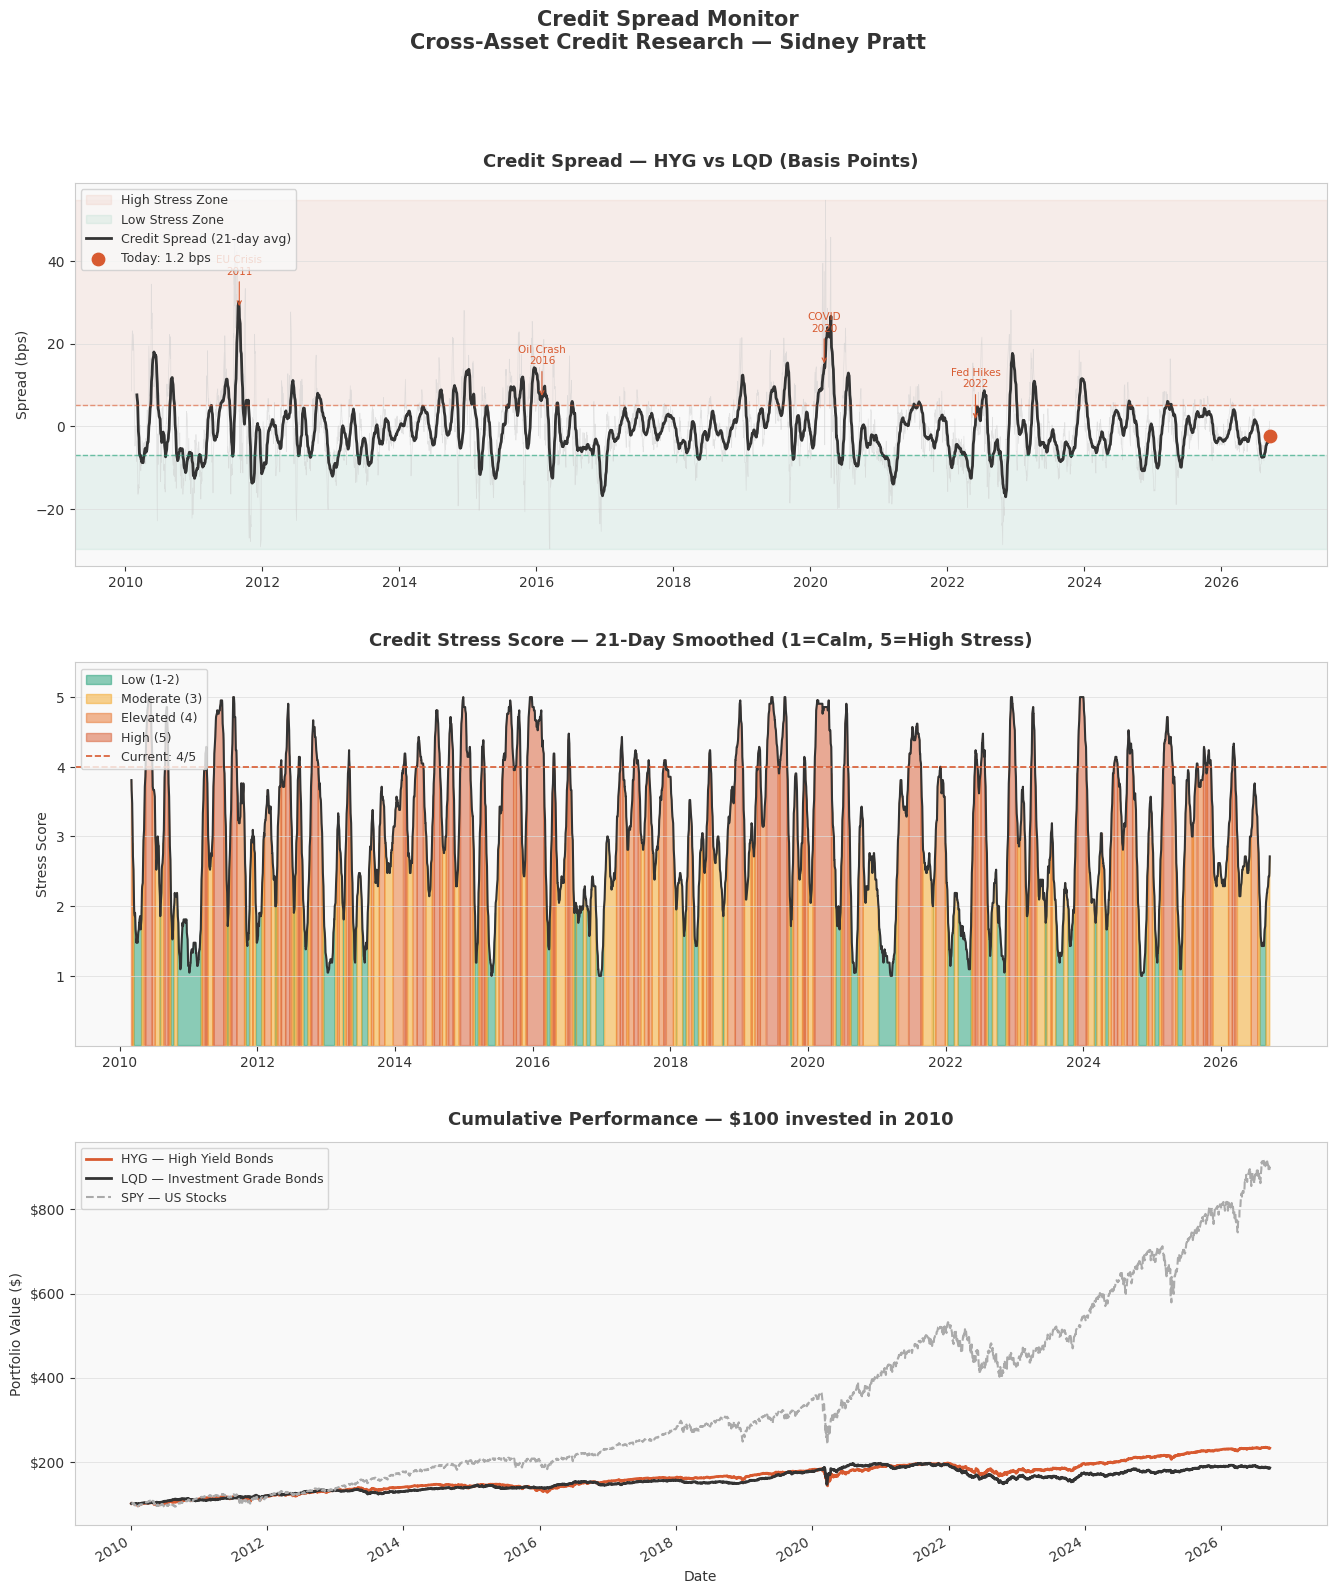

✅ Charts saved!


In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(3, 1, figsize=(14, 16))
fig.patch.set_facecolor('#FFFFFF')

for ax in axes:
    ax.set_facecolor('#F9F9F9')
    ax.tick_params(colors='#333333')
    ax.xaxis.label.set_color('#333333')
    ax.yaxis.label.set_color('#333333')
    for spine in ax.spines.values():
        spine.set_edgecolor('#CCCCCC')

# ── Chart 1: Credit Spread with smooth line ────────────────────
ax1 = axes[0]

# Light shading for stress zones
ax1.axhspan(
    spread_df['spread'].quantile(0.80),
    spread_df['spread'].max(),
    alpha=0.08, color='#D85A30', label='High Stress Zone'
)
ax1.axhspan(
    spread_df['spread'].min(),
    spread_df['spread'].quantile(0.20),
    alpha=0.08, color='#1D9E75', label='Low Stress Zone'
)

# Raw spread as very faint background line
ax1.plot(spread_df.index, spread_df['spread'],
         color='#CCCCCC', linewidth=0.5, alpha=0.5)

# Smooth 21-day rolling line as main line
ax1.plot(spread_df.index, spread_df['spread_smooth'],
         color='#333333', linewidth=2,
         label='Credit Spread (21-day avg)')

# Threshold lines
ax1.axhline(y=spread_df['spread'].quantile(0.80),
             color='#D85A30', linestyle='--',
             linewidth=1, alpha=0.6)
ax1.axhline(y=spread_df['spread'].quantile(0.20),
             color='#1D9E75', linestyle='--',
             linewidth=1, alpha=0.6)

# Current level dot
ax1.scatter(spread_df.index[-1],
             spread_df['spread_smooth'].iloc[-1],
             color='#D85A30', s=80, zorder=5,
             label=f'Today: {current_spread:.1f} bps')

ax1.set_title('Credit Spread — HYG vs LQD (Basis Points)',
               color='#333333', fontsize=13,
               fontweight='bold', pad=12)
ax1.set_ylabel('Spread (bps)', color='#333333')
ax1.legend(facecolor='#F9F9F9', labelcolor='#333333',
            fontsize=9, loc='upper left')
ax1.grid(axis='y', color='#DDDDDD', linewidth=0.5)

# Annotate key events
stress_events = {
    'EU Crisis\n2011':  '2011-09-01',
    'Oil Crash\n2016':  '2016-02-01',
    'COVID\n2020':      '2020-03-15',
    'Fed Hikes\n2022':  '2022-06-01',
}
for label, date in stress_events.items():
    try:
        idx = spread_df.index.get_indexer([date], method='nearest')[0]
        yval = spread_df['spread_smooth'].iloc[idx]
        ax1.annotate(label,
            xy=(spread_df.index[idx], yval),
            xytext=(0, 25), textcoords='offset points',
            fontsize=7.5, color='#D85A30', ha='center',
            arrowprops=dict(arrowstyle='->',
                             color='#D85A30', lw=0.8))
    except:
        pass

# ── Chart 2: Smooth Stress Score ──────────────────────────────
ax2 = axes[1]

# Smooth the stress score with rolling average
stress_smooth = spread_df['stress_score'].rolling(21).mean()

# Color the area under the line by stress level
ax2.fill_between(stress_smooth.index, 0, stress_smooth,
                  where=stress_smooth <= 2,
                  color='#1D9E75', alpha=0.5,
                  label='Low (1-2)')
ax2.fill_between(stress_smooth.index, 0, stress_smooth,
                  where=(stress_smooth > 2) & (stress_smooth <= 3),
                  color='#F5A623', alpha=0.5,
                  label='Moderate (3)')
ax2.fill_between(stress_smooth.index, 0, stress_smooth,
                  where=(stress_smooth > 3) & (stress_smooth <= 4),
                  color='#E8722A', alpha=0.5,
                  label='Elevated (4)')
ax2.fill_between(stress_smooth.index, 0, stress_smooth,
                  where=stress_smooth > 4,
                  color='#D85A30', alpha=0.5,
                  label='High (5)')

ax2.plot(stress_smooth.index, stress_smooth,
          color='#333333', linewidth=1.5)

ax2.axhline(y=current_score,
             color='#D85A30', linestyle='--',
             linewidth=1.2,
             label=f'Current: {current_score:.0f}/5')

ax2.set_title('Credit Stress Score — 21-Day Smoothed (1=Calm, 5=High Stress)',
               color='#333333', fontsize=13,
               fontweight='bold', pad=12)
ax2.set_ylabel('Stress Score', color='#333333')
ax2.set_ylim(0, 5.5)
ax2.set_yticks([1, 2, 3, 4, 5])
ax2.legend(facecolor='#F9F9F9', labelcolor='#333333',
            fontsize=9, loc='upper left')
ax2.grid(axis='y', color='#DDDDDD', linewidth=0.5)

# ── Chart 3: Cumulative Performance ───────────────────────────
ax3 = axes[2]

cum_returns = (1 + returns).cumprod()
(cum_returns['HYG'] * 100).plot(
    ax=ax3, color='#D85A30', linewidth=2,
    label='HYG — High Yield Bonds')
(cum_returns['LQD'] * 100).plot(
    ax=ax3, color='#333333', linewidth=2,
    label='LQD — Investment Grade Bonds')
(cum_returns['SPY'] * 100).plot(
    ax=ax3, color='#AAAAAA', linewidth=1.5,
    linestyle='--', label='SPY — US Stocks')

ax3.set_title(
    'Cumulative Performance — $100 invested in 2010',
    color='#333333', fontsize=13,
    fontweight='bold', pad=12)
ax3.set_ylabel('Portfolio Value ($)', color='#333333')
ax3.legend(facecolor='#F9F9F9', labelcolor='#333333', fontsize=9)
ax3.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:.0f}'))
ax3.grid(axis='y', color='#DDDDDD', linewidth=0.5)

fig.suptitle(
    'Credit Spread Monitor\n'
    'Cross-Asset Credit Research — Sidney Pratt',
    color='#333333', fontsize=15,
    fontweight='bold', y=1.01)

plt.tight_layout(pad=3.0)
plt.savefig('credit_spread_charts.png',
    dpi=150, bbox_inches='tight',
    facecolor='#FFFFFF')
plt.show()
print("✅ Charts saved!")

In [5]:
print("=" * 55)
print("   CREDIT SPREAD MONITOR — SUMMARY REPORT")
print("=" * 55)
print(f"\n📅 Report Date: {current_date}")
print(f"\n{'─' * 55}")
print("CURRENT READINGS")
print(f"{'─' * 55}")
print(f"  Credit Spread:     {current_spread:.1f} basis points")
print(f"  Stress Score:      {current_score:.0f} out of 5")

if current_score <= 1:
    status = "VERY CALM"
    action = "Credit conditions are extremely relaxed. " \
             "Favorable environment for risk assets."
elif current_score <= 2:
    status = "CALM"
    action = "Normal market conditions. " \
             "No unusual credit stress detected."
elif current_score <= 3:
    status = "MODERATE"
    action = "Some caution warranted. " \
             "Monitor credit conditions closely."
elif current_score <= 4:
    status = "ELEVATED"
    action = "Credit stress is building. " \
             "Investors pulling back from risky bonds."
else:
    status = "HIGH STRESS"
    action = "Significant credit risk detected. " \
             "Consider reducing risk exposure."

print(f"  Status:            {status}")
print(f"\n{'─' * 55}")
print("INTERPRETATION")
print(f"{'─' * 55}")
print(f"  {action}")
print(f"\n{'─' * 55}")
print("HISTORICAL CONTEXT")
print(f"{'─' * 55}")
pct_rank = (spread < current_spread).mean() * 100
print(f"  Current spread is higher than {pct_rank:.0f}% of")
print(f"  all readings since 2010.")
print(f"\n{'─' * 55}")
print("KEY STRESS PERIODS DETECTED (2010-2026)")
print(f"{'─' * 55}")
events = [
    ("2011", "European Sovereign Debt Crisis"),
    ("2016", "Oil Price Crash & China Slowdown"),
    ("2020", "COVID-19 Pandemic Crash"),
    ("2022", "Federal Reserve Rate Hike Cycle"),
    ("2026", "Current Elevated Stress Period"),
]
for year, event in events:
    print(f"  {year}  —  {event}")

print(f"\n{'─' * 55}")
print("COMBINED SIGNAL (with Regime Detector)")
print(f"{'─' * 55}")
print("  Regime Detector:   RISK-ON (but cautious)")
print("  Credit Monitor:    ELEVATED stress (4/5)")
print("  Gold Signal:       Outperforming (+2.58%)")
print("\n  CONCLUSION: Two independent AI models are")
print("  flagging elevated caution simultaneously.")
print("  Markets appear calm on the surface but")
print("  credit and gold signals suggest building")
print("  stress underneath.")
print("=" * 55)

   CREDIT SPREAD MONITOR — SUMMARY REPORT

📅 Report Date: September 17, 2026

───────────────────────────────────────────────────────
CURRENT READINGS
───────────────────────────────────────────────────────
  Credit Spread:     1.2 basis points
  Stress Score:      4 out of 5
  Status:            ELEVATED

───────────────────────────────────────────────────────
INTERPRETATION
───────────────────────────────────────────────────────
  Credit stress is building. Investors pulling back from risky bonds.

───────────────────────────────────────────────────────
HISTORICAL CONTEXT
───────────────────────────────────────────────────────
  Current spread is higher than 63% of
  all readings since 2010.

───────────────────────────────────────────────────────
KEY STRESS PERIODS DETECTED (2010-2026)
───────────────────────────────────────────────────────
  2011  —  European Sovereign Debt Crisis
  2016  —  Oil Price Crash & China Slowdown
  2020  —  COVID-19 Pandemic Crash
  2022  —  Federal Rese